In [12]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar


OPTIMAL QUANTITIES
   rho  q_unhedged    q_hedged        gap
0  0.5   85.357143  100.599131  15.241988
1  0.6   93.521739  105.707841  12.186102
2  0.7   99.245763  109.046907   9.801144
3  0.8  103.351351  111.329339   7.977987
4  0.9  106.368132  112.950179   6.582047
5  1.0  108.636364  114.138814   5.502450


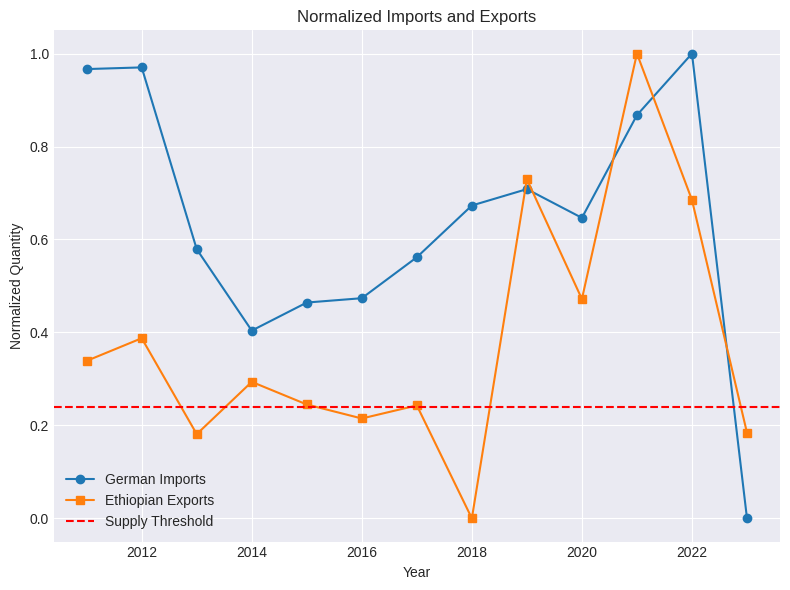

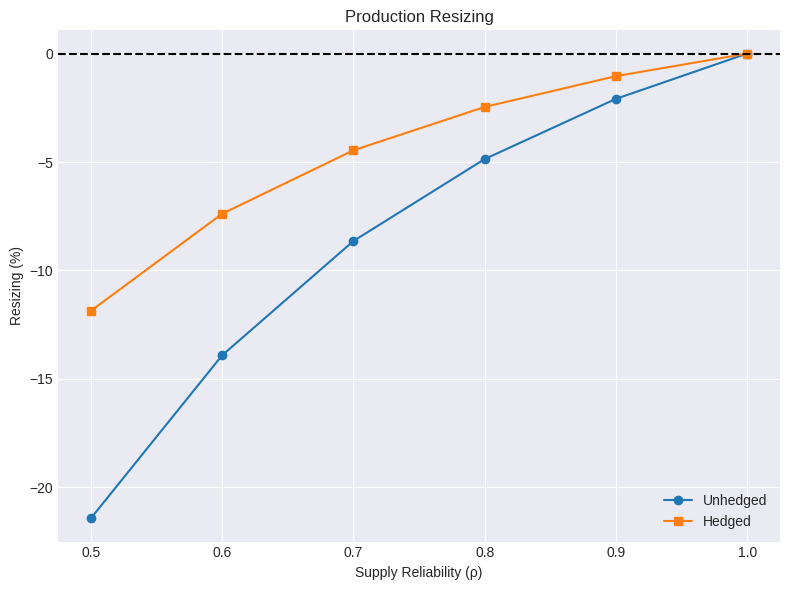


Monotonic Unhedged: True
Monotonic Hedged: True

FINAL RESULTS
   rho  q_unhedged    q_hedged        gap  resize_unhedged  resize_hedged
0  0.5   85.357143  100.599131  15.241988       -21.428571     -11.862470
1  0.6   93.521739  105.707841  12.186102       -13.913043      -7.386596
2  0.7   99.245763  109.046907   9.801144        -8.644068      -4.461153
3  0.8  103.351351  111.329339   7.977987        -4.864865      -2.461454
4  0.9  106.368132  112.950179   6.582047        -2.087912      -1.041394
5  1.0  108.636364  114.138814   5.502450         0.000000       0.000000


In [18]:
# ==========================================================
# OPTIMAL INVENTORY AND HEDGING UNDER SUPPLY FRAGILITY


# ==========================================================
# DATA (2010-2023) - ALL IN KG
# ==========================================================

# Export data (Ethiopia to Germany) - Quantity in kg
export_data = {
    2010: 31500346, 2011: 31665300, 2012: 34017380, 2013: 24053620,
    2014: 29483160, 2015: 27133860, 2016: 25680468, 2017: 27038240,
    2018: 15308080, 2019: 50527100, 2020: 38085430, 2021: 63582300,
    2022: 48379010, 2023: 24202210
}

# Import data (Germany from Ethiopia) - Quantity in kg
import_data = {
    2010: 65227545, 2011: 56796738, 2012: 56922015, 2013: 43310844,
    2014: 37218136, 2015: 39319295, 2016: 39643849, 2017: 42710107,
    2018: 46583663, 2019: 47810214, 2020: 45658882, 2021: 53348132,
    2022: 57957366, 2023: 23163808
}

years = list(range(2010, 2024))

df = pd.DataFrame({
    "year": years,
    "E_t": [export_data[y] for y in years],
    "D_t": [import_data[y] for y in years]
})

# ==========================================================
# SUPPLY SUCCESS INDICATOR 
# ==========================================================

tau = 0.8 * df["E_t"].mean()
df["Y_t"] = (df["E_t"] >= tau).astype(int)

# ==========================================================
# HEDGE FACTOR 
# ==========================================================

df["X_t"] = np.log(df["D_t"]).diff()
df = df.dropna().reset_index(drop=True)

# ==========================================================
# LOGIT MODEL 
# ==========================================================

X = sm.add_constant(df["X_t"])
y = df["Y_t"]

logit_model = sm.Logit(y, X)
result = logit_model.fit(disp=0)

df["p_hat"] = result.predict(X)

eta_sq_hat = np.mean(df["p_hat"]**2)
rho_hat = df["Y_t"].mean()

# ==========================================================
# PARAMETERS 
# ==========================================================

alpha = 120
beta = 1

p = 8.0
c = 4.0
a = 0.8

# OPERATING PROFIT 
def M(q):
    return alpha * q - 0.5 * beta * q**2

def expected_profit(q, rho):
    return rho * (p * M(q) - c * q)

# ==========================================================
# VARIANCE STRUCTURE
# Γ(q,ρ) = q² / ρ 
# ==========================================================

def Gamma(q, rho):
    return (q**2) / rho

# ==========================================================
# VALUE FUNCTIONS
# ==========================================================

def V0(q, rho):
    return expected_profit(q, rho) - 0.5 * a * Gamma(q, rho)

def V_hedged(q, rho):
    return expected_profit(q, rho) - 0.5 * a * (1 - eta_sq_hat) * Gamma(q, rho)

# ==========================================================
# OPTIMISATION
# ==========================================================

rho_grid = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

results = []

for rho in rho_grid:

    res0 = minimize_scalar(
        lambda q: -V0(q, rho),
        bounds=(0, 200),
        method="bounded"
    )

    q0 = res0.x

    resH = minimize_scalar(
        lambda q: -V_hedged(q, rho),
        bounds=(0, 200),
        method="bounded"
    )

    qH = resH.x

    results.append({
        "rho": rho,
        "q_unhedged": q0,
        "q_hedged": qH,
        "gap": qH - q0
    })

results_df = pd.DataFrame(results)

# ==========================================================
# PRINT TABLE
# ==========================================================

print("\nOPTIMAL QUANTITIES")
print(results_df)

# ==========================================================
# RESIZING MEASURES 
# ==========================================================

q0_ref = results_df.loc[results_df["rho"] == 1.0, "q_unhedged"].values[0]
qH_ref = results_df.loc[results_df["rho"] == 1.0, "q_hedged"].values[0]

results_df["resize_unhedged"] = (results_df["q_unhedged"] - q0_ref) / q0_ref * 100
results_df["resize_hedged"] = (results_df["q_hedged"] - qH_ref) / qH_ref * 100

# ==========================================================
# FIGURE 1 
# ==========================================================

imports_norm = (df["D_t"] - df["D_t"].min()) / (df["D_t"].max() - df["D_t"].min())
exports_norm = (df["E_t"] - df["E_t"].min()) / (df["E_t"].max() - df["E_t"].min())
threshold_norm = (tau - df["E_t"].min()) / (df["E_t"].max() - df["E_t"].min())

plt.figure(figsize=(8,6))

plt.plot(df["year"], imports_norm, "o-", label="German Imports")
plt.plot(df["year"], exports_norm, "s-", label="Ethiopian Exports")

plt.axhline(y=threshold_norm, color="red", linestyle="--",
            label="Supply Threshold")

plt.xlabel("Year")
plt.ylabel("Normalized Quantity")
plt.title("Normalized Imports and Exports")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("normalized_import_export_plot.png", dpi=300)
plt.show()

# ==========================================================
# FIGURE 2
# ==========================================================

plt.figure(figsize=(8,6))

plt.plot(results_df["rho"], results_df["resize_unhedged"], "o-", label="Unhedged")
plt.plot(results_df["rho"], results_df["resize_hedged"], "s-", label="Hedged")

plt.axhline(y=0, color="black", linestyle="--")

plt.xlabel("Supply Reliability (ρ)")
plt.ylabel("Resizing (%)")
plt.title("Production Resizing")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("production_resizing_plot.png", dpi=300)
plt.show()

# ==========================================================
# VERIFICATION 
# ==========================================================

all_inc_u = np.all(np.diff(results_df["q_unhedged"]) > 0)
all_inc_h = np.all(np.diff(results_df["q_hedged"]) > 0)

print("\nMonotonic Unhedged:", all_inc_u)
print("Monotonic Hedged:", all_inc_h)

print("\nFINAL RESULTS")
print(results_df)